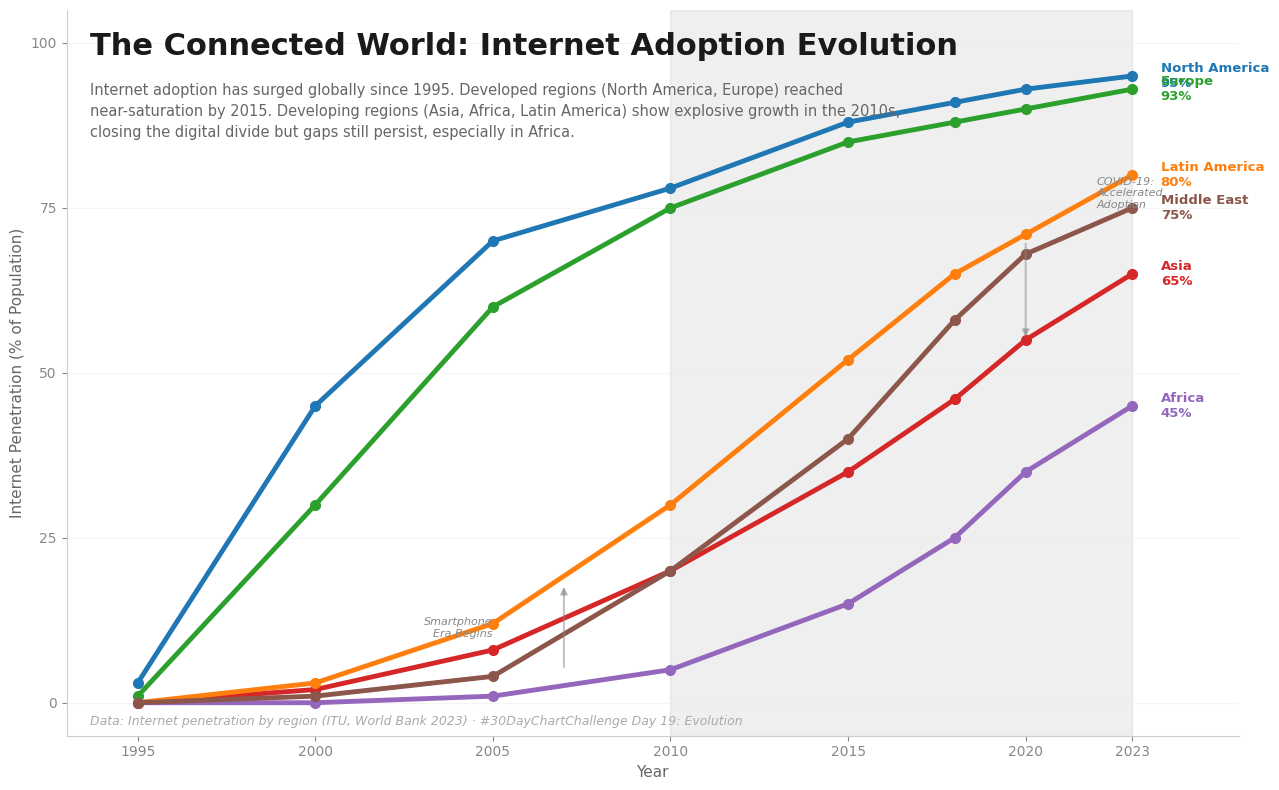

In [1]:
"""
#30DayChartChallenge — Day 19: Evolution
"The Connected World: Internet Adoption Over Time" — timeseries evolution
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Global internet adoption by region over time (1995-2023)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Internet penetration (% of population) by region
# ---------------------------------------------------------------------------
data = {
    "Year": [1995, 2000, 2005, 2010, 2015, 2018, 2020, 2023],
    "North_America": [3, 45, 70, 78, 88, 91, 93, 95],
    "Europe": [1, 30, 60, 75, 85, 88, 90, 93],
    "Asia": [0, 2, 8, 20, 35, 46, 55, 65],
    "Latin_America": [0, 3, 12, 30, 52, 65, 71, 80],
    "Africa": [0, 0, 1, 5, 15, 25, 35, 45],
    "Middle_East": [0, 1, 4, 20, 40, 58, 68, 75]
}

df = pd.DataFrame(data)

# ---------------------------------------------------------------------------
# 2. PLOT — Stacked area chart showing global evolution
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 8), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Colors for each region
colors = {
    "North_America": "#1f77b4",
    "Europe": "#2ca02c",
    "Asia": "#d62728",
    "Latin_America": "#ff7f0e",
    "Africa": "#9467bd",
    "Middle_East": "#8c564b"
}

# Plot lines (not stacked, just layered) to show individual trajectories
regions = ["North_America", "Europe", "Asia", "Latin_America", "Africa", "Middle_East"]
region_labels = ["North America", "Europe", "Asia", "Latin America", "Africa", "Middle East"]

for region, label in zip(regions, region_labels):
    ax.plot(df["Year"], df[region], color=colors[region], linewidth=3.5, marker="o",
            markersize=7, label=label, zorder=3)

# Add annotations at end of each line
for region, label in zip(regions, region_labels):
    last_year = df["Year"].iloc[-1]
    last_value = df[region].iloc[-1]
    
    ax.text(last_year + 0.8, last_value, f"{label}\n{last_value}%",
            fontsize=9.5, fontweight="600", color=colors[region], va="center")

# Highlight the inflection points (2010s boom)
ax.axvspan(2010, 2023, alpha=0.08, color="#333333", zorder=0, label="Digital boom era")

# Minimal styling
ax.set_xlim(1993, 2026)
ax.set_ylim(-5, 105)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#cccccc")
ax.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, axis="y", zorder=0)
ax.set_axisbelow(True)

ax.set_xlabel("Year", fontsize=11, color="#666666", fontweight="500")
ax.set_ylabel("Internet Penetration (% of Population)", fontsize=11, color="#666666", fontweight="500")
ax.set_xticks([1995, 2000, 2005, 2010, 2015, 2020, 2023])
ax.set_yticks([0, 25, 50, 75, 100])
ax.tick_params(colors="#888888", labelsize=10)

# Title & subtitle
ax.text(0.02, 0.97, "The Connected World: Internet Adoption Evolution",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.90,
        "Internet adoption has surged globally since 1995. Developed regions (North America, Europe) reached\n"
        "near-saturation by 2015. Developing regions (Asia, Africa, Latin America) show explosive growth in the 2010s,\n"
        "closing the digital divide but gaps still persist, especially in Africa.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Key milestone annotations
ax.annotate("", xy=(2007, 18), xytext=(2007, 5),
            arrowprops=dict(arrowstyle="-|>", color="#888888", lw=1.5, alpha=0.5))
ax.text(2005, 10, "Smartphone\nEra Begins",
        fontsize=8, color="#888888", style="italic", ha="right")

ax.annotate("", xy=(2020, 55), xytext=(2020, 70),
            arrowprops=dict(arrowstyle="-|>", color="#888888", lw=1.5, alpha=0.5))
ax.text(2022, 75, "COVID-19:\nAccelerated\nAdoption",
        fontsize=8, color="#888888", style="italic", ha="left")

# Source
ax.text(0.02, 0.01,
        "Data: Internet penetration by region (ITU, World Bank 2023) · #30DayChartChallenge Day 19: Evolution",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="bottom")

plt.tight_layout()
plt.savefig("day19_evolution.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()